In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# 1. 加载数据与预处理
df = pd.read_csv('/Users/i590389/Downloads/data/ms46131a-4To43.5GHz-2048-brick01-200mm-0deg/1.csv')
freq = df['FREQ'] / 1e9  # 转换为 GHz
real = df['REAL']
imag = df['IMAG']

# 2. 设置专业风格
plt.rcParams['font.sans-serif'] = ['Arial']
color_real = "#69B9D9" # 蓝色
color_imag = "#DBAA72" # 红色
color_bg = "#f5f5f5"   # 浅灰色背景

# 3. 创建布局 (2行：主图 + 概览图)
fig = plt.figure(figsize=(12, 12), facecolor='white')
gs = fig.add_gridspec(2, 1, height_ratios=[4, 1], hspace=0.3)
ax_main = fig.add_subplot(gs[0])
ax_ov = fig.add_subplot(gs[1])

# --- 主图初始化 ---
ax_main.set_facecolor(color_bg)
ax_main.grid(True, linestyle='--', alpha=0.5, color='white')
ax_main.set_ylabel('Amplitude', fontsize=10, fontweight='bold')
ax_main.set_title('RF Signal: Real & Imaginary Components', loc='left', fontsize=12, fontweight='bold')
line_real, = ax_main.plot([], [], color=color_real, lw=2, label='Real')
line_imag, = ax_main.plot([], [], color=color_imag, lw=2, label='Imaginary')
ax_main.legend(loc='upper right')
for spine in ax_main.spines.values(): spine.set_visible(False)

# --- 概览图初始化 ---
ax_ov.plot(freq, real, color=color_real, alpha=1, lw=0.5)
ax_ov.plot(freq, imag, color=color_imag, alpha=1, lw=0.5)
ax_ov.set_facecolor(color_bg)
ax_ov.set_yticks([])
ax_ov.set_xlabel('Frequency (GHz)', fontsize=10, fontweight='bold')
for spine in ax_ov.spines.values(): spine.set_visible(False)

# 滑动高亮方块 (Overview Window)
rect = plt.Rectangle((0, -1), 0, 2, color='#333333', alpha=0.15)
ax_ov.add_patch(rect)

# 动态文本
freq_text = ax_main.text(0.02, 0.92, '', transform=ax_main.transAxes, fontweight='bold')

# 4. 动画参数
window_size = 5    # 每次显示的频段宽度 (5 GHz)
num_frames = 520   # 动画帧数

def init():
    ax_main.set_ylim(min(real.min(), imag.min())*1.2, max(real.max(), imag.max())*1.2)
    rect.set_width(window_size)
    ax_ov.set_ylim(-1, 1) # 确保高亮块覆盖
    return line_real, line_imag, rect, freq_text

def update(frame):
    # 计算滑动范围
    total_range = freq.max() - freq.min() - window_size
    start_f = freq.min() + (frame / num_frames) * total_range
    end_f = start_f + window_size
    
    # 截取当前窗口数据
    mask = (freq >= start_f) & (freq <= end_f)
    line_real.set_data(freq[mask], real[mask])
    line_imag.set_data(freq[mask], imag[mask])
    
    ax_main.set_xlim(start_f, end_f)
    rect.set_xy((start_f, -1)) # 更新概览图高亮位置
    freq_text.set_text(f'Band: {start_f:.2f} - {end_f:.2f} GHz')
    
    return line_real, line_imag, rect, freq_text

# 5. 生成动画
ani = animation.FuncAnimation(fig, update, frames=num_frames, init_func=init, blit=True)

# 如果你本地安装了 ffmpeg，可以保存为 mp4:
# ani.save('rf_scan_video.mp4', writer='ffmpeg', fps=30)

# 或者保存为 GIF:
ani.save('./brick01_rf_scan.gif', writer='pillow', fps=24)
plt.close()

In [13]:
# 1. 加载数据与预处理
df = pd.read_csv('/Users/i590389/Downloads/data/ms46131a-4To43.5GHz-2048-wood01-200mm-0deg/1.csv')
freq = df['FREQ'] / 1e9  # 转换为 GHz
real = df['REAL']
imag = df['IMAG']

# 2. 设置专业风格
plt.rcParams['font.sans-serif'] = ['Arial']
color_real = '#85C3DC' # 蓝色
color_imag = '#E2C098' # 红色
color_bg = "#f5f5f5"   # 浅灰色背景

# 3. 创建布局 (2行：主图 + 概览图)
fig = plt.figure(figsize=(12, 7), facecolor='white')
gs = fig.add_gridspec(2, 1, height_ratios=[4, 1], hspace=0.3)
ax_main = fig.add_subplot(gs[0])
ax_ov = fig.add_subplot(gs[1])

# --- 主图初始化 ---
ax_main.set_facecolor(color_bg)
ax_main.grid(True, linestyle='--', alpha=0.5, color='white')
ax_main.set_ylabel('Amplitude', fontsize=10, fontweight='bold')
ax_main.set_title('RF Signal: Real & Imaginary Components', loc='left', fontsize=12, fontweight='bold')
line_real, = ax_main.plot([], [], color=color_real, lw=2, label='Real')
line_imag, = ax_main.plot([], [], color=color_imag, lw=2, label='Imaginary')
ax_main.legend(loc='upper right')
for spine in ax_main.spines.values(): spine.set_visible(False)

# --- 概览图初始化 ---
ax_ov.plot(freq, real, color=color_real, alpha=1, lw=0.5)
ax_ov.plot(freq, imag, color=color_imag, alpha=1, lw=0.5)
ax_ov.set_facecolor(color_bg)
ax_ov.set_yticks([])
ax_ov.set_xlabel('Frequency (GHz)', fontsize=10, fontweight='bold')
for spine in ax_ov.spines.values(): spine.set_visible(False)

# 滑动高亮方块 (Overview Window)
rect = plt.Rectangle((0, -1), 0, 2, color='#333333', alpha=0.15)
ax_ov.add_patch(rect)

# 动态文本
freq_text = ax_main.text(0.02, 0.92, '', transform=ax_main.transAxes, fontweight='bold')

# 4. 动画参数
window_size = 5    # 每次显示的频段宽度 (5 GHz)
num_frames = 520   # 动画帧数

def init():
    ax_main.set_ylim(min(real.min(), imag.min())*1.2, max(real.max(), imag.max())*1.2)
    rect.set_width(window_size)
    ax_ov.set_ylim(-1, 1) # 确保高亮块覆盖
    return line_real, line_imag, rect, freq_text

def update(frame):
    # 计算滑动范围
    total_range = freq.max() - freq.min() - window_size
    start_f = freq.min() + (frame / num_frames) * total_range
    end_f = start_f + window_size
    
    # 截取当前窗口数据
    mask = (freq >= start_f) & (freq <= end_f)
    line_real.set_data(freq[mask], real[mask])
    line_imag.set_data(freq[mask], imag[mask])
    
    ax_main.set_xlim(start_f, end_f)
    rect.set_xy((start_f, -1)) # 更新概览图高亮位置
    freq_text.set_text(f'Band: {start_f:.2f} - {end_f:.2f} GHz')
    
    return line_real, line_imag, rect, freq_text

# 5. 生成动画
ani = animation.FuncAnimation(fig, update, frames=num_frames, init_func=init, blit=True)

# 如果你本地安装了 ffmpeg，可以保存为 mp4:
# ani.save('rf_scan_video.mp4', writer='ffmpeg', fps=30)

# 或者保存为 GIF:
ani.save('./wood01_rf_scan.gif', writer='pillow', fps=24)
plt.close()

MovieWriter ffmpeg unavailable; using Pillow instead.


ValueError: unknown file extension: .mp4

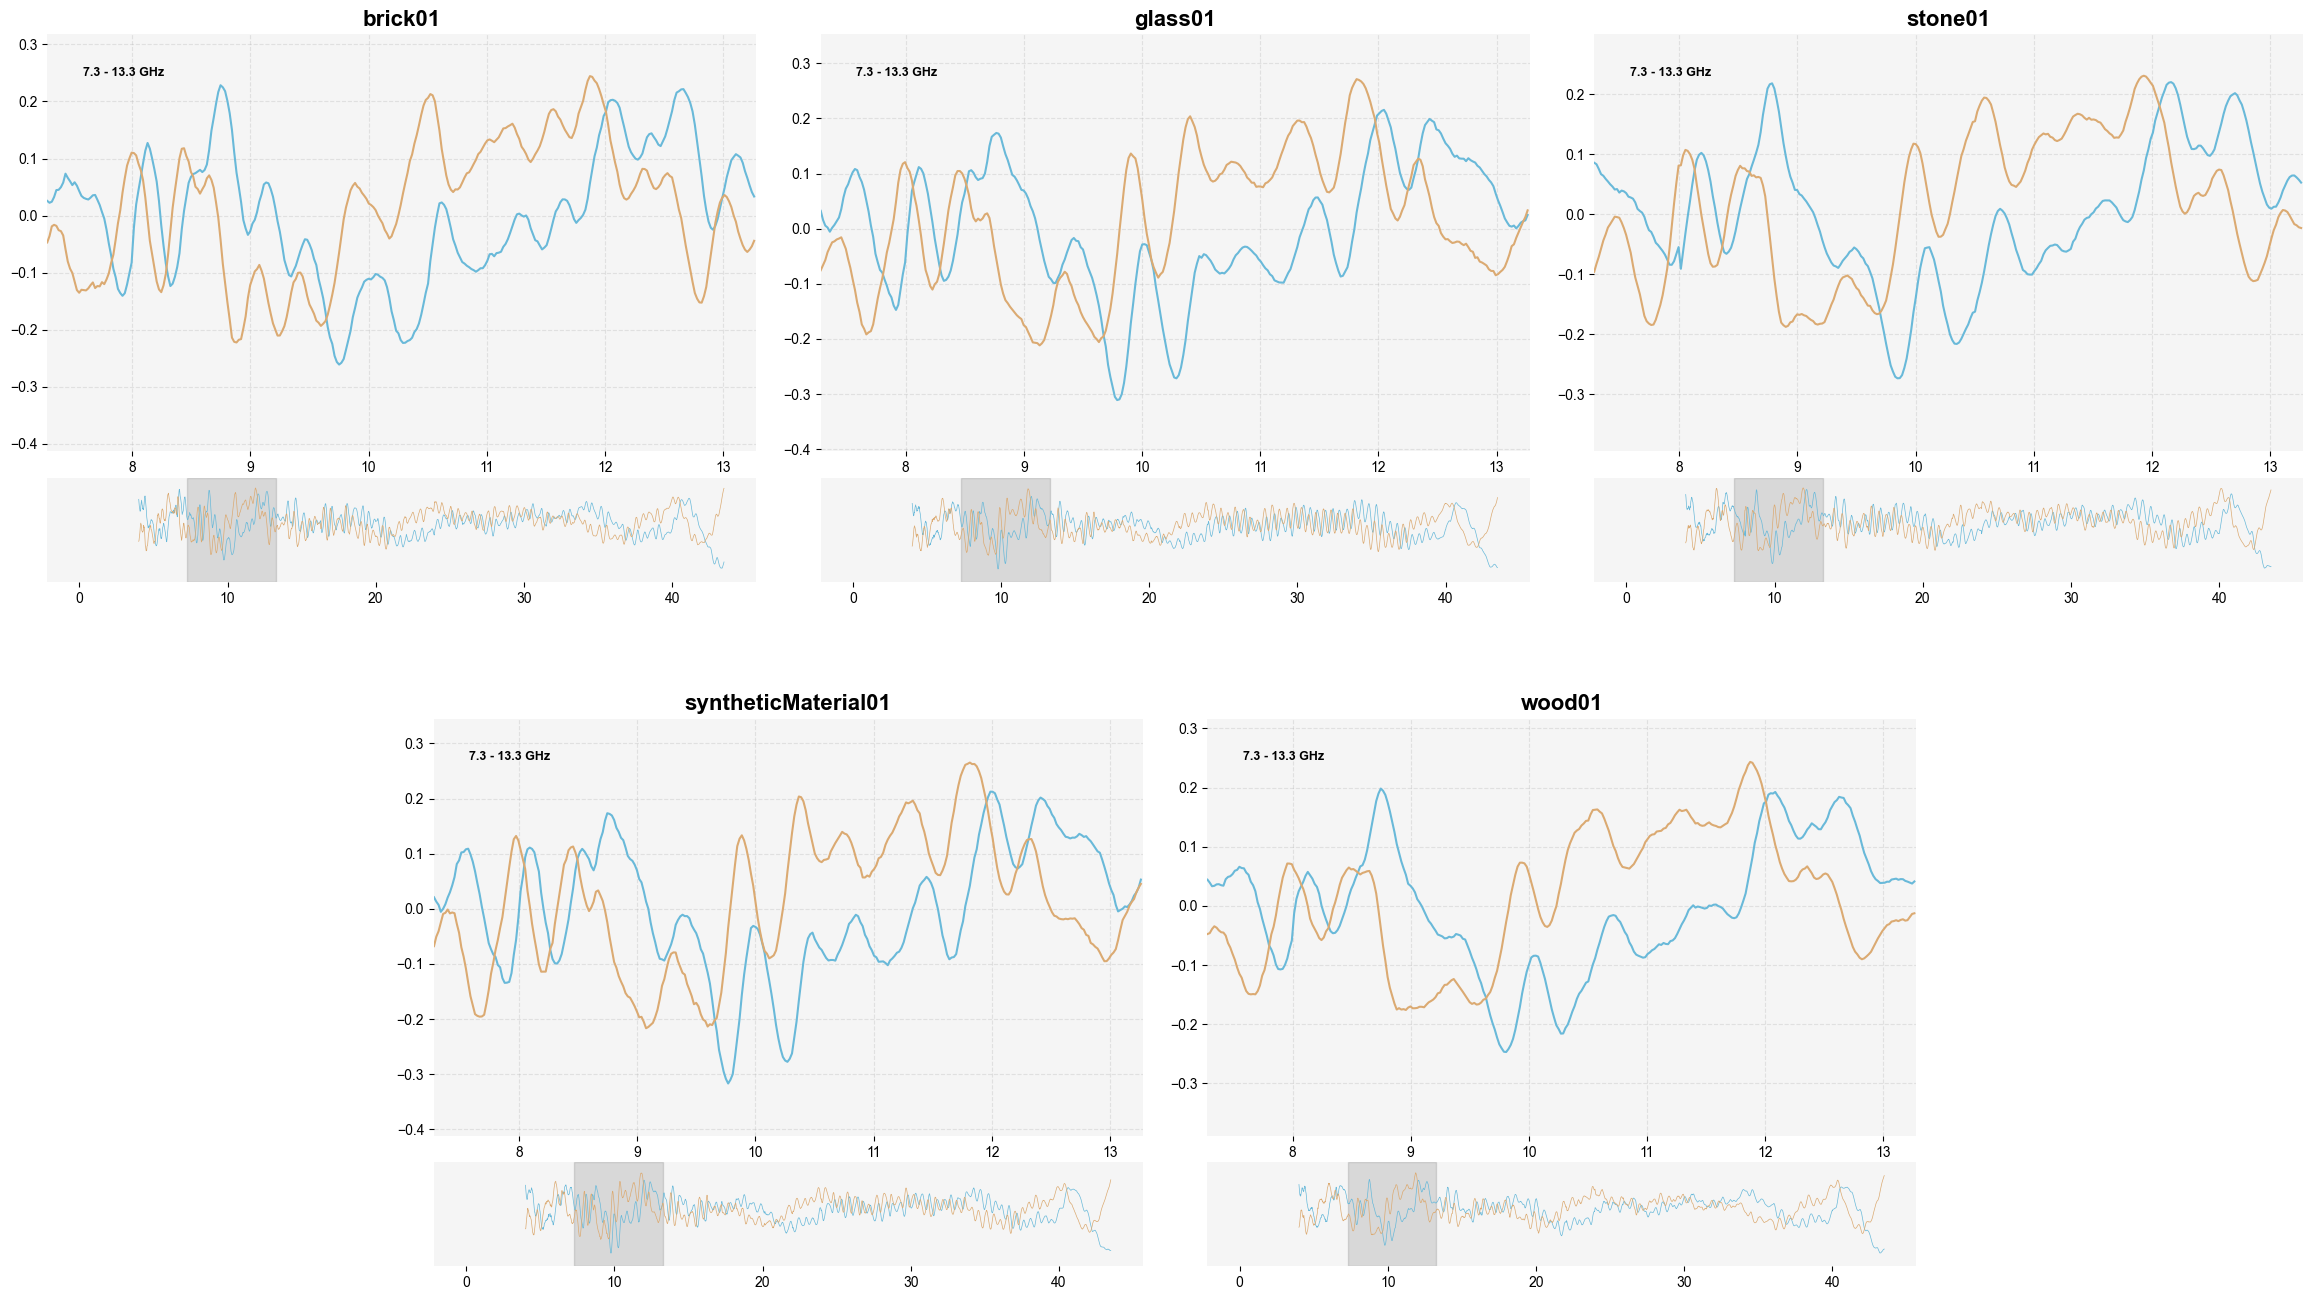

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.gridspec as gridspec
import numpy as np

# 1. 配置文件列表 (请确保这5个文件在你的路径下)
file_list = ['/Users/i590389/Downloads/data/ms46131a-4To43.5GHz-2048-brick01-200mm-0deg/1.csv',
             '/Users/i590389/Downloads/data/ms46131a-4To43.5GHz-2048-glass01-200mm-0deg/1.csv',
             '/Users/i590389/Downloads/data/ms46131a-4To43.5GHz-2048-stone01-200mm-0deg/1.csv',
             '/Users/i590389/Downloads/data/ms46131a-4To43.5GHz-2048-syntheticMaterial01-200mm-0deg/1.csv',
             '/Users/i590389/Downloads/data/ms46131a-4To43.5GHz-2048-wood01-200mm-0deg/1.csv']
# 注意：如果文件不足5个，下面的循环会报错，你可以先用同一个文件占位测试

# 2. 设置画布与 3+2 复杂布局
# 我们使用 6 列的网格：第一行每张图占 2 列；第二行两张图各占 2 列并从第 2 列开始排，从而实现居中
fig = plt.figure(figsize=(24, 14), facecolor='white', dpi=100) 
outer_gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.25, wspace=0.2)

# 强制消除四周边缘留白 (left, right, bottom, top 的范围是 0-1)
fig.subplots_adjust(left=0.03, right=0.97, bottom=0.05, top=0.93)
# 颜色与视觉配置
color_real = "#69B9D9" # 蓝色
color_imag = "#DBAA72" # 红色
color_bg = "#f5f5f5"   # 浅灰色背景
window_size = 6.0  # 观察窗口大小 (GHz)
num_frames = 480   # 动画总帧数

# 存储每个子图的组件以便更新
data_sources = []
axes_main, lines_r, lines_i, rects, texts = [], [], [], [], []

# 3. 初始化所有子图
for i in range(5):
    # 确定位置：前3个在第一行，后2个在第二行并居中
    if i < 3:
        subplot_spec = outer_gs[0, i*2 : i*2+2]
    else:
        # i=3 占 cols 1-2, i=4 占 cols 3-4
        subplot_spec = outer_gs[1, (i-3)*2+1 : (i-3)*2+3]
    
    # 每个子块内部分为：主图 (4份高) 和 概览图 (1份高)
    inner_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=subplot_spec, 
                                               height_ratios=[4, 1], hspace=0.1)
    
    # 加载数据 (如果没有对应文件，这里可以加个 try-except)
    df = pd.read_csv(file_list[i])
    f, r, m = df['FREQ'].values / 1e9, df['REAL'].values, df['IMAG'].values
    data_sources.append({'f': f, 'r': r, 'm': m, 'label': f'Sample {i+1}'})

    # 创建主图
    ax_m = fig.add_subplot(inner_gs[0])
    ax_m.set_facecolor(color_bg)
    ax_m.set_title(f"{file_list[i].split('/')[-2].split('-')[-3]}", fontweight='bold', fontsize=16)
    lr, = ax_m.plot([], [], color=color_real, lw=1.5)
    li, = ax_m.plot([], [], color=color_imag, lw=1.5)
    ax_m.set_ylim(min(r.min(), m.min())*1.3, max(r.max(), m.max())*1.3)
    for s in ax_m.spines.values(): s.set_visible(False)
    ax_m.grid(True, ls='--', alpha=0.3)
    
    # 创建概览图
    ax_o = fig.add_subplot(inner_gs[1])
    ax_o.plot(f, r, color=color_real, alpha=1, lw=0.5)
    ax_o.plot(f, m, color=color_imag, alpha=1, lw=0.5)
    ax_o.set_facecolor(color_bg)
    ax_o.set_yticks([])
    for s in ax_o.spines.values(): s.set_visible(False)
    
    # 概览图中的滑动方块
    rect = plt.Rectangle((0, -2), window_size, 4, color='#333333', alpha=0.15)
    ax_o.add_patch(rect)
    ax_o.set_ylim(ax_m.get_ylim()) # 让概览图的Y轴与主图一致
    
    # 动态文本
    txt = ax_m.text(0.05, 0.9, '', transform=ax_m.transAxes, fontsize=9, fontweight='bold')
    
    axes_main.append(ax_m)
    lines_r.append(lr)
    lines_i.append(li)
    rects.append(rect)
    texts.append(txt)

# 4. 动画更新函数
def update(frame):
    updated_artists = []
    for i in range(5):
        data = data_sources[i]
        total_range = data['f'].max() - data['f'].min() - window_size
        start_f = data['f'].min() + (frame / num_frames) * total_range
        end_f = start_f + window_size
        
        mask = (data['f'] >= start_f) & (data['f'] <= end_f)
        lines_r[i].set_data(data['f'][mask], data['r'][mask])
        lines_i[i].set_data(data['f'][mask], data['m'][mask])
        
        axes_main[i].set_xlim(start_f, end_f)
        rects[i].set_xy((start_f, axes_main[i].get_ylim()[0]))
        rects[i].set_height(axes_main[i].get_ylim()[1] - axes_main[i].get_ylim()[0])
        texts[i].set_text(f'{start_f:.1f} - {end_f:.1f} GHz')
        
        updated_artists.extend([lines_r[i], lines_i[i], rects[i], texts[i]])
    return updated_artists

# 5. 保存动画
ani = animation.FuncAnimation(fig, update, frames=num_frames, blit=True)
# ani.save('rf_3plus2_matrix.gif', writer='pillow', fps=32)
ani.save('rf_3plus2_matrix.mp4', writer='ffmpeg', fps=24, bitrate=2000)
plt.show()